# 1. Import Ntuple and DecayHash

In [5]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
from termcolor import colored
import pandas
import numpy as np
from tqdm import tqdm
tqdm.pandas()
plt.style.use('belle2')

In [7]:
# read in root-file as a pandas dataframe
samples = {}
files = ['sigDDst', 'normDDst','bkgDststp_tau', 'bkgDstst0_tau','bkgDstst0_ell']

Dstst_e_nu_selection = 'DecayMode=="all_Dstst_e_nu" and D_mcPDG*e_mcPDG==411*11 and e_genMotherPDG==B0_mcPDG and \
    ((B0_mcErrors<64 and B0_mcPDG*D_mcPDG==-511*411) or (B0_mcErrors<512 and abs(B0_mcPDG)==521))'
Dstst_tau_nu_selection = 'DecayMode=="all_Dstst_tau_nu" and D_mcPDG*e_mcPDG==411*11 and e_mcPDG*e_genMotherPDG==11*15 and \
    ((B0_mcErrors<64 and B0_mcPDG*D_mcPDG==-511*411) or (B0_mcErrors<512 and abs(B0_mcPDG)==521))'
signals_selection = 'B0_mcPDG*D_mcPDG==-511*411 and D_mcPDG*e_mcPDG==411*11 and e_mcPDG*e_genMotherPDG==11*15'
norms_selection = 'B0_mcPDG*D_mcPDG==-511*411 and D_mcPDG*e_mcPDG==411*11 and e_genMotherPDG==B0_mcPDG'


for file_name in tqdm(files, desc=colored('Loading parquets', 'blue')):
    filename=f'/home/belle/zhangboy/R_D/Signal_MC14ri/MC14ri_{file_name}_bengal_e_2/{file_name}_bengal_e_2_0.parquet'
    data = pandas.read_parquet(filename, engine="pyarrow")
    
    # Signal components
    if file_name == files[0]:
        sig_D_tau_nu=data.query(f'DecayMode=="sig_D_tau_nu" and B0_mcErrors<32 and {signals_selection}').copy()
        sig_Dst_tau_nu=data.query(f'DecayMode=="sig_Dst_tau_nu" and B0_mcErrors<64 and {signals_selection}').copy()
        samples[r'$D\tau\nu$'] = sig_D_tau_nu
        samples[r'$D^\ast\tau\nu$'] = sig_Dst_tau_nu
        
    if file_name == files[1]:
        sig_D_e_nu=data.query(f'DecayMode=="sig_D_e_nu" and B0_mcErrors<16 and {norms_selection}').copy()
        sig_Dst_e_nu=data.query(f'DecayMode=="sig_Dst_e_nu" and B0_mcErrors<64 and {norms_selection}').copy()
        Dstst_e_nu_p=data.query(Dstst_e_nu_selection).copy()
        samples[r'$D\ell\nu$'] = sig_D_e_nu
        samples[r'$D^\ast\ell\nu$'] = sig_Dst_e_nu
        
    if file_name == files[2]:
        Dstst_tau_nu_p=data.query(Dstst_tau_nu_selection).copy()
        
    if file_name == files[3]:
        Dstst_tau_nu_0=data.query(Dstst_tau_nu_selection).copy()
        samples[r'$D^{\ast\ast}\tau\nu$'] = pandas.concat([Dstst_tau_nu_p,Dstst_tau_nu_0])
        
    if file_name == files[4]:
        Dstst_e_nu_0=data.query(Dstst_e_nu_selection).copy()
        samples[r'$D^{\ast\ast}\ell\nu$'] = pandas.concat([Dstst_e_nu_p,Dstst_e_nu_0])


    #sig_D_mu_nu=df_bestSelected.query('DecayMode=="sig_D_mu_nu" and B0_mcErrors<16').copy()
    #sig_Dst_mu_nu=df_bestSelected.query('DecayMode=="sig_Dst_mu_nu" and (16<=B0_mcErrors<32 or B0_mcErrors<8)').copy()
    #all_Dstst_mu_nu=df_bestSelected.query('DecayMode=="all_Dstst_mu_nu" and (16<=B0_mcErrors<64 or B0_mcErrors<8)').copy()

    # Bkg components
#     bkg_fakeD = df_bestSelected.query('abs(D_mcPDG)!=411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()
#     bkg_fakeTracksClusters = df_bestSelected.query('B0_mcErrors==512 and B0_isContinuumEvent!=1').copy()
#     bkg_fakeDTC = pandas.concat([bkg_fakeD, bkg_fakeTracksClusters])

#     bkg_combinatorial = df_bestSelected.query('B0_mcPDG==300553 and abs(D_mcPDG)==411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()
#     bkg_sigOtherBDTaudecay = df_bestSelected.query('(DecayMode=="bkg" or DecayMode=="sig_D_mu_nu" or DecayMode=="sig_Dst_mu_nu" or DecayMode=="all_Dstst_mu_nu") and \
#     B0_mcPDG!=300553 and abs(D_mcPDG)==411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()
#     bkg_fakeB = pandas.concat([bkg_combinatorial, bkg_sigOtherBDTaudecay])

#     bkg_continuum = df_bestSelected.query('B0_isContinuumEvent==1').copy()

#     bkg_others = pandas.concat([df_bestSelected,
#                                sig_D_e_nu,
#                                sig_D_tau_nu,
#                                sig_Dst_e_nu,
#                                sig_Dst_tau_nu,
#                                all_Dstst_e_nu,
#                                all_Dstst_tau_nu,
#                                bkg_fakeDTC,
#                                bkg_fakeB,
#                                bkg_continuum]).drop_duplicates(keep=False)
    # Weird! the bkg_others contains some events with
    # correct sig decay hash chain and correct B0_mcPDG, D_mcPDG, e_genMotherPDG,
    # but with 128< B0_mcErrors < 256 (misID)

Loading parquets: 100%|██████████| 5/5 [00:20<00:00,  4.11s/it]


In [12]:
def statistics(df):
    counts=df.count()
    mean=df.mean()
    std=df.std()
    return f'''counts = %d \nmean = %5.3f \nstd = %5.3f''' %(counts,mean,std)

kwarg={'histtype':'step','lw':2}
    

plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab20.colors)

def plot_all_signals(cut, variable):
    fig,axs =plt.subplots(2,3,figsize=(16,10), sharex=True, sharey=False)
    fig.suptitle(f'All signals with {cut}')
    fig.supylabel('# of candidates per bin',x=0.06)
    fig.supxlabel(f'{variable}', y=0.06)
    i=0
    j=0
    for sample_name, sample in samples.items():
        (counts, bins) = np.histogram(sample.query(cut)[variable], bins=50)
        if sample_name in ['sig_D_l_nu','sig_D_tau_nu','bkg_fakeDTC','bkg_fakeB','bkg_continuum','bkg_others']:
            factor = 1
        elif sample_name in ['sig_Dst_l_nu','sig_Dst_tau_nu','all_Dstst_l_nu','all_Dstst_tau_nu']:
            factor = 1
        axs[i,j].hist(bins[:-1], bins, weights=factor*counts,label=sample_name,**kwarg)

        #plt.legend(bbox_to_anchor=(1,1),ncol=3, fancybox=True, shadow=True,labelspacing=1.5)
        axs[i,j].grid()
        axs[i,j].set_title(sample_name)
        j+=1
        if j==3:
            i+=1
            j=0
            
def plot_all_signals_2d(cut):
    variable_x = 'B0_CMS3_weMissM2'
    variable_y = 'p_D_l'
    xedges = np.linspace(-2, 10, 48)
    yedges = np.linspace(0.4, 4.6, 42)

    n_rows,n_cols = [2,3]
    fig,axs=plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16,8),sharex=True, sharey='all')
    fig.suptitle('Signal MC')
    fig.supylabel('$|p_D|\ +\ |p_l|\ [GeV]$', x=0.05)
    fig.supxlabel('$M_{miss}^2\ [GeV^2/c^4]$')
    i=0
    j=0
    for name, sample in samples.items():
        (counts, xedges, yedges) = np.histogram2d(sample.query(cut)[variable_x], 
                                              sample.query(cut)[variable_y],
                                              bins=[xedges, yedges])
        counts = counts.T # + 0.0001
        X, Y = np.meshgrid(xedges, yedges)
        im=axs[i,j].pcolormesh(X, Y, counts, cmap='jet', norm=colors.LogNorm())
        axs[i,j].grid()
        axs[i,j].set_xlim(xedges.min(),xedges.max())
        axs[i,j].set_ylim(yedges.min(),yedges.max())
        axs[i,j].set_title(name,fontsize=12)
        fig.colorbar(im,ax=axs[i,j])
        j+=1
        if j==3:
            i+=1
            j=0
            
def plot_overlaid_signals(cut, variable):
    fig,axs =plt.subplots(1,2,figsize=(12,5), sharex=True, sharey=False)
    fig.suptitle(f'Overlaid signals with pre-selection', y=1)
    fig.supylabel('# of candidates per bin',x=0.06)
    #fig.supxlabel('$|\\vec{p_D}|\ +\ |\\vec{p_l}|$  [GeV/c]')
    #fig.supxlabel('$M_{miss}^2 \ [GeV^2/c^4]$')
    fig.supxlabel(f'{variable}')

    for sample_name, sample in samples.items():
        (counts, bins) = np.histogram(sample.query(cut)[variable], bins=50)
        factor=1
        if sample_name in ['sig_D_tau_nu','sig_Dst_tau_nu','all_Dstst_tau_nu']:
            axs[0].hist(bins[:-1], bins, weights=factor*counts,label=sample_name,**kwarg)
            axs[0].legend()
        elif sample_name in ['sig_D_l_nu','sig_Dst_l_nu','all_Dstst_l_nu']:
            axs[1].hist(bins[:-1], bins, weights=factor*counts,label=sample_name,**kwarg)
            axs[1].legend()
        #plt.legend(bbox_to_anchor=(1,1),ncol=3, fancybox=True, shadow=True,labelspacing=1.5)

    axs[0].set_title('signals')
    axs[1].set_title('normalization')
    axs[0].grid()
    axs[1].grid()
    
def plot_projection(cut,variable):
    fig,axs =plt.subplots(sharex=True, sharey=False)
    for sample_name, sample in samples.items():
        (counts, bins) = np.histogram(sample.query(cut)[variable], bins=50)
        factor=1
        if sample_name in ['sig_D_tau_nu','sig_Dst_tau_nu','all_Dstst_tau_nu']:
            axs.hist(bins[:-1], bins, weights=factor*counts,label=f'{sample_name} \n{statistics(sample.query(cut)[variable])}',**kwarg)
        elif sample_name in ['sig_D_l_nu','sig_Dst_l_nu','all_Dstst_l_nu']:
            axs.hist(bins[:-1], bins, weights=factor*counts,label=f'{sample_name} \n{statistics(sample.query(cut)[variable])}',**kwarg)

    axs.set_title('Overlaid signals with pre-selection')
    axs.set_xlabel(f'{variable}')
    axs.set_ylabel('# of candidates per bin')
    axs.grid()
    plt.legend(bbox_to_anchor=(1,1),ncol=3, fancybox=True, shadow=True,labelspacing=1.5)

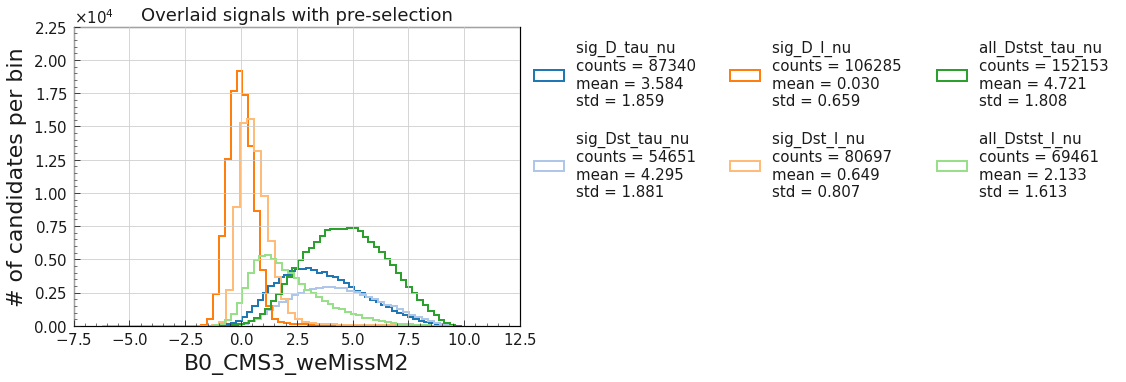

In [4]:
plot_projection('B0_roeMbc_my_mask>5', 'B0_CMS3_weMissM2')

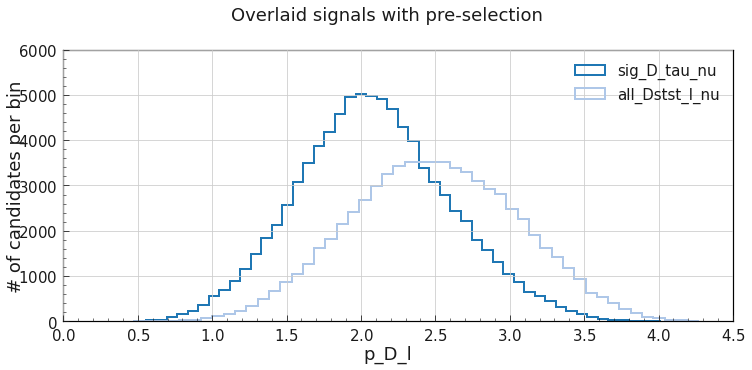

In [5]:
plot_overlaid_signals_2('B0_roeMbc_my_mask>5', 'p_D_l')

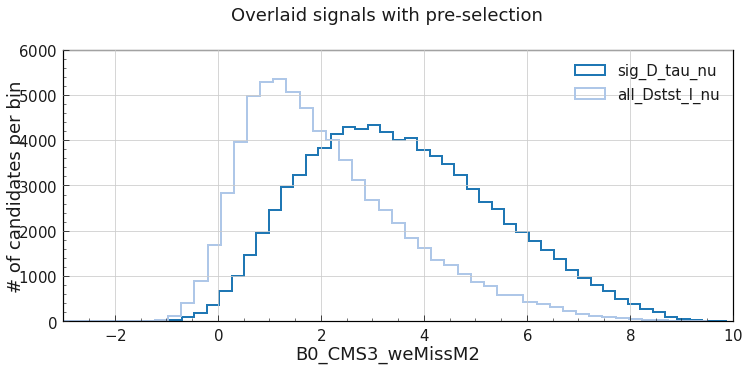

In [6]:
plot_overlaid_signals_2('B0_roeMbc_my_mask>5', 'B0_CMS3_weMissM2')
plt.xlim(-3,10);

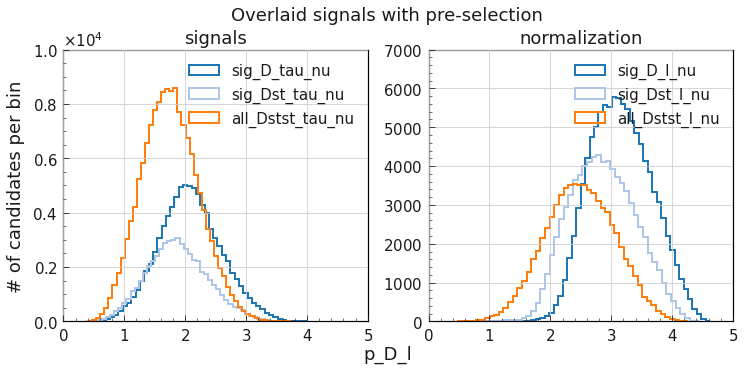

In [7]:
plot_overlaid_signals('B0_roeMbc_my_mask>5', 'p_D_l')

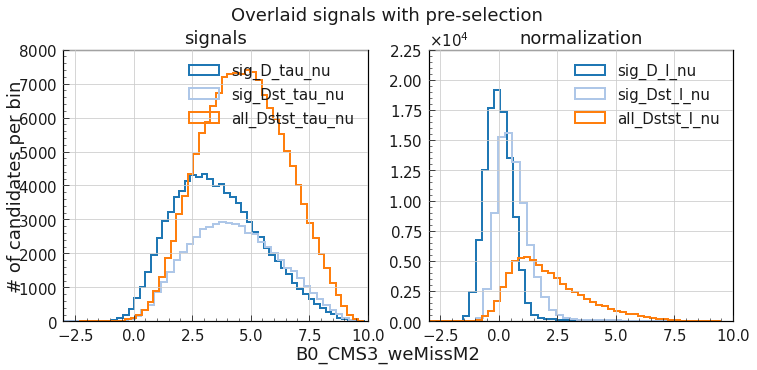

In [8]:
plot_overlaid_signals('B0_roeMbc_my_mask>5', 'B0_CMS3_weMissM2')
plt.xlim(-3,10);

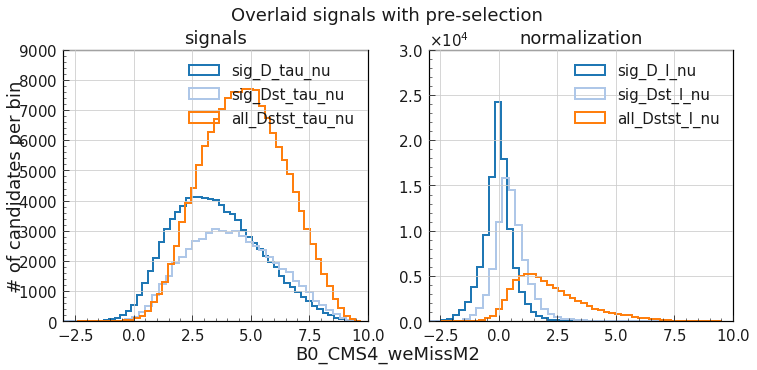

In [9]:
plot_overlaid_signals('B0_roeMbc_my_mask>5', 'B0_CMS4_weMissM2')
plt.xlim(-3,10);

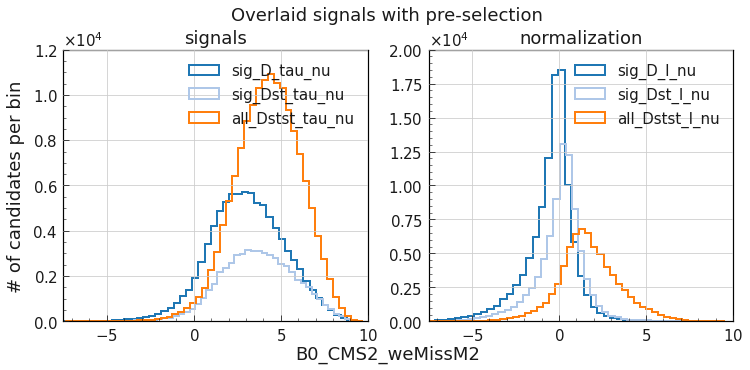

In [16]:
plot_overlaid_signals('B0_roeMbc_my_mask>5', 'B0_CMS2_weMissM2')
plt.xlim(-7.5,10);

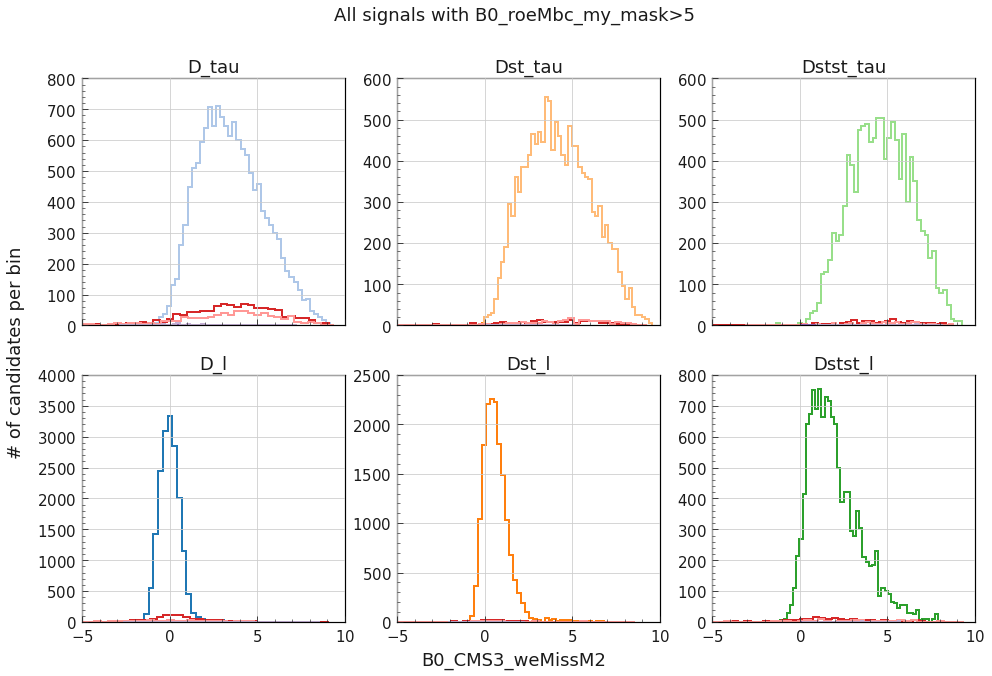

In [21]:
plot_all_signals('B0_roeMbc_my_mask>5', 'B0_CMS3_weMissM2')
plt.xlim(-5,10);

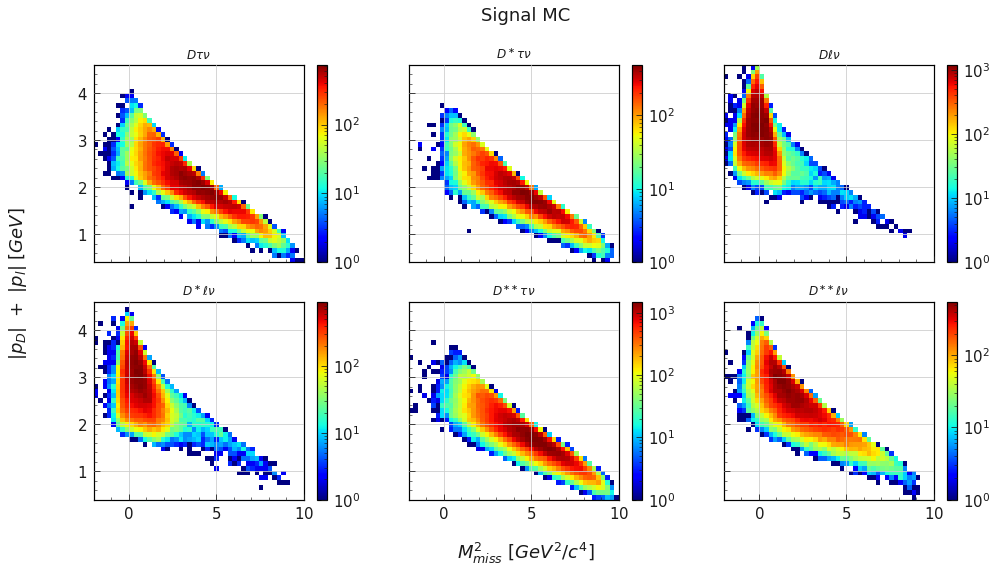

In [13]:
plot_all_signals_2d('B0_roeMbc_my_mask>5')

# 4. Build fitting templates

In [18]:
import json

workspace_file = '/home/belle/zhangboy/R_D/Signal_MC14ri/2d_2channels_workspace_2.json'
cut='B0_roeMbc_my_mask>4'
xedges = np.linspace(-7.5, 10, 48) # -7.5 for weMiss2, -2 for weMiss3, -2.5 for weMiss4
yedges = np.linspace(0.4, 4.6, 42)
variable_x = 'B0_CMS2_weMissM2'
variable_y = 'p_D_l'
i = 0

for name, sample in samples.items():
    (counts, xedges, yedges) = np.histogram2d(sample.query(cut)[variable_x], 
                                              sample.query(cut)[variable_y],
                                              bins=[xedges, yedges])
    counts = counts.T + 0.01

    with open(workspace_file, 'r+') as f:
        data = json.load(f)
        data['channels'][0]['samples'][i]['name'] = name
        data['channels'][0]['samples'][i]['data'] = counts.ravel().tolist()
        # counts.ravel()/.reshape(-1) returns a view, counts.flatten() returns a copy (slower)
        f.seek(0)        # <--- should reset file position to the beginning.
        json.dump(data, f, indent=4)
        f.truncate()     # remove remaining part

    i += 1

# BDT

In [8]:
import basf2_mva
import pandas

identifier_1 = '/home/belle/zhangboy/R_D/Generic_MC14rd/Continuum_Suppression/MVA1_FastBDT.xml'
test_1 = '../Ntuples/MC_eidglobal_10k_cut.root'
output_file_1 = '../Ntuples/MC_eidglobal_10k_MVA1.root'

identifier_1_5 = '/home/belle/zhangboy/R_D/Generic_MC14rd/B_bkg_Suppression/MVA1_5/MVA1_5_FastBDT.xml'
test_1_5 = '../Ntuples/MC_eidglobal_10k_cut.root'
output_file_1_5 = '../Ntuples/MC_eidglobal_10k_MVA1_5.root'

output_file_1_5_applied = '../Ntuples/MC_eidglobal_10k_MVA1_5_applied.root'

identifier_2_1 = '/home/belle/zhangboy/R_D/Generic_MC14rd/B_bkg_Suppression/MVA2/MVA2_1_FastBDT.xml'
test_2_1 = output_file_1_5_applied
output_file_2_1 = '../Ntuples/MC_eidglobal_10k_MVA2_1.root'
output_file_2_1_applied = '../Ntuples/MC_eidglobal_10k_MVA2_1_applied.root'

In [9]:
# apply CS BDT identifier_1, merge data file and mva output, rename the column
basf2_mva.expert(basf2_mva.vector(identifier_1),  # weightfile
                 basf2_mva.vector(test_1),
                 'B0', output_file_1)

df1 = df_cut.drop_duplicates(subset=['__experiment__','__run__','__event__','__production__','__candidate__']).reset_index(drop=True)
df2 = root_pandas.read_root(output_file_1)
print(len(df1)==len(df2))
df_1 = pandas.concat([df1,df2],axis=1)

df_1=df_1.rename(columns={"__slhome__slbelle__slzhangboy__slR_D__slGeneric_MC14rd__slContinuum_Suppression__slMVA1_FastBDT__ptxml": "MVA1_output"})
df_1=df_1.drop(columns=['__slhome__slbelle__slzhangboy__slR_D__slGeneric_MC14rd__slContinuum_Suppression__slMVA1_FastBDT__ptxml_isSignal'])

# apply BDT 1_5 identifier_1_5, merge, rename, change the output type, save
basf2_mva.expert(basf2_mva.vector(identifier_1_5),  # weightfile
                 basf2_mva.vector(test_1_5),
                 'B0', output_file_1_5)

df3 = root_pandas.read_root(output_file_1_5)
print(len(df_1)==len(df3))
df_1_5 = pandas.concat([df_1,df3],axis=1)

df_1_5=df_1_5.rename(columns={"__slhome__slbelle__slzhangboy__slR_D__slGeneric_MC14rd__slB_bkg_Suppression__slMVA1_5__slMVA1_5_FastBDT__ptxml": "MVA1_5_output"})
df_1_5=df_1_5.drop(columns=['__slhome__slbelle__slzhangboy__slR_D__slGeneric_MC14rd__slB_bkg_Suppression__slMVA1_5__slMVA1_5_FastBDT__ptxml_isSignal'])

df_1_5.MVA1_5_output=np.float64(df_1_5.MVA1_5_output)
print(type(df_1_5.MVA1_5_output[0]))
print(type(df_1_5.isSignal[0]))

df_1_5.to_root(output_file_1_5_applied, key='B0')

# apply BDT 2_1 identifier_2_1, merge, rename, save
basf2_mva.expert(basf2_mva.vector(identifier_2_1),  # weightfile
                 basf2_mva.vector(test_2_1),
                 'B0', output_file_2_1)

df4 = root_pandas.read_root(output_file_2_1)
print(len(df_1_5)==len(df4))
df_2_1 = pandas.concat([df_1_5, df4],axis=1)
print(len(df_1_5)==len(df_2_1))

df_2_1=df_2_1.rename(columns={"__slhome__slbelle__slzhangboy__slR_D__slGeneric_MC14rd__slB_bkg_Suppression__slMVA2__slMVA2_1_FastBDT__ptxml": "MVA2_1_output"})
df_2_1=df_2_1.drop(columns=['__slhome__slbelle__slzhangboy__slR_D__slGeneric_MC14rd__slB_bkg_Suppression__slMVA2__slMVA2_1_FastBDT__ptxml_isSignal'])

df_2_1.to_root(output_file_2_1_applied, key='B0')

[INFO] Elapsed application time in ms 19.8755 for MVA1_FastBDT.xml
[WARNING] String passed to makeROOTCompatible contains double-underscore __, which is used internally for escaping special characters. It is recommended to avoid this. However escaping a string twice with makeROOTCompatible is safe, but will print this warning. Passed string: __slhome__slbelle__slzhangboy__slR_D__slGeneric_MC14rd__slContinuum_Suppression__slMVA1_FastBDT__ptxml_isSignal
False
[INFO] Elapsed application time in ms 17.8737 for MVA1_5_FastBDT.xml
[WARNING] String passed to makeROOTCompatible contains double-underscore __, which is used internally for escaping special characters. It is recommended to avoid this. However escaping a string twice with makeROOTCompatible is safe, but will print this warning. Passed string: __slhome__slbelle__slzhangboy__slR_D__slGeneric_MC14rd__slB_bkg_Suppression__slMVA1_5__slMVA1_5_FastBDT__ptxml_isSignal
True
<class 'numpy.float64'>
<class 'numpy.float64'>


/cvmfs/belle.cern.ch/el7/externals/v01-10-02/Linux_x86_64/common/lib/python3.8/site-packages/root_numpy/_tree.py:575: UserWarning: converter for dtype('O') is not implemented (skipping)
  cobj = _librootnumpy.array2tree_toCObj(arr, name=name, tree=incobj)


[INFO] Elapsed application time in ms 16.9586 for MVA2_1_FastBDT.xml
[WARNING] String passed to makeROOTCompatible contains double-underscore __, which is used internally for escaping special characters. It is recommended to avoid this. However escaping a string twice with makeROOTCompatible is safe, but will print this warning. Passed string: __slhome__slbelle__slzhangboy__slR_D__slGeneric_MC14rd__slB_bkg_Suppression__slMVA2__slMVA2_1_FastBDT__ptxml_isSignal
True
True


In [10]:
df_2_1.columns
len(df_2_1)

1589